In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/perf_dal /home/dhuseljic/mlflow

import os 
import mlflow
import torch
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib
from datetime import datetime

os.makedirs('plots', exist_ok=True)
matplotlib.rcParams['figure.figsize'] = (4, 3)
torch.set_grad_enabled(False)


def filter_by_date(runs, year, month, day, hour=0, min=0, fn=np.greater):
    filtered_runs = []
    for run in runs:
        start_time = datetime.fromtimestamp(run.info.start_time / 1000) # in ms
        filter_time = datetime(year, month, day, hour, min)
        if fn(start_time, filter_time):
            filtered_runs.append(run)
    return filtered_runs

def rename_parameter(run, param_name, name):
    run.data.params[param_name] = name
    return run

import json
from pathlib import Path

def download_artifacts(run, to_path=Path.home() / 'server_artifacts'):
    global_uri = Path(run.info.artifact_uri)
    local_uri = Path(*global_uri.parts[-4:])
    dest = to_path / local_uri
    os.makedirs(dest, exist_ok=True)
    print(f'Downloading artifacts from {global_uri} to {dest}')
    os.system(f'rsync -avz cluster.ies:{global_uri}/ {dest}')
    return dest

receiving incremental file list

sent 25 bytes  received 136 bytes  64.40 bytes/sec
total size is 226,684,928  speedup is 1,407,980.92


In [2]:
from collections import defaultdict

exp_name = 'oracle_v7'
dataset = 'cifar10'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'

runs = []

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'random'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_)

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'typiclust'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_)

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'cross_domain_oracle'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_)

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'perf_dal_oracle'", "parameter.al.optimal.num_batches = '300'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs_ = [rename_parameter(run, 'al.strategy', 'perf_300') for run in runs_]
runs.extend(runs_)

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'perf_dal_oracle'", "parameter.al.optimal.num_batches = '900'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs_ = [rename_parameter(run, 'al.strategy', 'perf_900') for run in runs_]
runs.extend(runs_)

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'perf_dal_oracle'", "parameter.al.optimal.num_batches = '2000'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs_ = [rename_parameter(run, 'al.strategy', 'perf_2000') for run in runs_]
runs.extend(runs_)


# runs1 = filter_by_date(runs, 2024, 11, 29, 13, 10, fn=np.less)
# runs2 = filter_by_date(runs, 2024, 11, 29, 15, 50)
# runs = runs1 + runs2

print('Found {} experiments'.format(len(runs)))


runs_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

acc_curves_random = acc_curves_strategies['random']

for key in  acc_curves_strategies:
    print(f"{key:10}: {len(acc_curves_strategies[key]):3}")

# run = runs_per_strat['optimal'][0]
# params = run.data.params
# {key: val for key, val in params.items() if key.startswith('al')}

Found 20 experiments
perf_900  :  20
random    :   0


In [3]:
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)
axis_single = np.arange(acq_size, (acq_size*(num_acq+1))+1, 1)

IndexError: list index out of range

In [4]:
plt.figure(figsize=(4, 3))

for key in acc_curves_strategies:
    try:
        plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), label=key)
    except:
        plt.plot(axis_single, np.mean(acc_curves_strategies[key], axis=0), label=key)

plt.tight_layout()
plt.legend()

NameError: name 'axis_single' is not defined

<Figure size 400x300 with 0 Axes>

In [5]:
plt.figure(figsize=(4, 3))

acc_random = np.mean(acc_curves_random, axis=0)
for key in acc_curves_strategies:
    try:
        plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - acc_random , label=key)
    except:
        acc_random_interp = np.interp(axis_single, axis, acc_random)
        plt.plot(axis_single, np.mean(acc_curves_strategies[key]- acc_random_interp, axis=0), label=key)

plt.tight_layout()
plt.legend()

/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NameError: name 'axis_single' is not defined

<Figure size 400x300 with 0 Axes>

## How does an optimal strategy select batches?

In [6]:
bought_dict = defaultdict(list)
buy_matrix = []
for run in runs_per_strat['perf_900']:
    bought_random = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_random')]
    bought_diverse = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_diverse')]
    bought_uncertain = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_uncertain')]

    bought_dict['bought_random'].append(bought_random) 
    bought_dict['bought_diverse'].append(bought_diverse) 
    bought_dict['bought_uncertain'].append(bought_uncertain) 

    buys_m = np.stack((bought_random, bought_diverse, bought_uncertain), axis=1)
    buy_matrix.append(buys_m[1:] - buys_m[:-1])

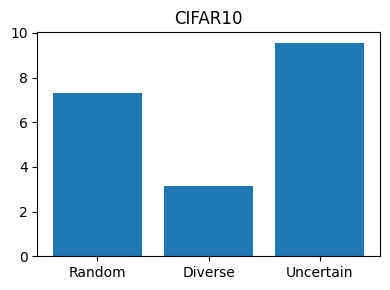

In [7]:
bought_random = np.mean(np.array(bought_dict['bought_random'])[:, -1])
bought_diverse = np.mean(np.array(bought_dict['bought_diverse'])[:, -1])
bought_uncertain = np.mean(np.array(bought_dict['bought_uncertain'])[:, -1])

x = np.arange(3)
plt.title(f'{dataset.upper()}')
plt.bar(x, [bought_random, bought_diverse, bought_uncertain], tick_label=['Random', 'Diverse', 'Uncertain'])
plt.tight_layout()
plt.savefig(f'plots/{dataset}_bought_overall.pdf')
plt.show()

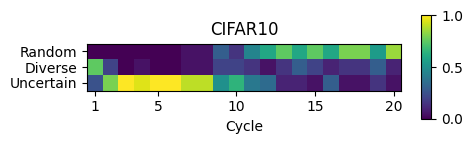

In [9]:
plt.figure(figsize=(5, 5))
plt.title(dataset.upper())
plt.imshow(np.mean(buy_matrix, axis=0).T, vmin=0, vmax=1)
plt.yticks([0, 1, 2], ['Random', 'Diverse', 'Uncertain'])
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('Cycle')
plt.colorbar(location='right', shrink=.22, aspect=10)
plt.tight_layout()
plt.savefig(f'plots/{dataset}_bought_per_cycle.pdf', bbox_inches='tight')
plt.show()

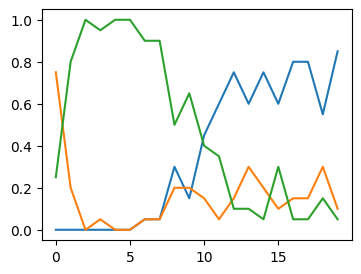

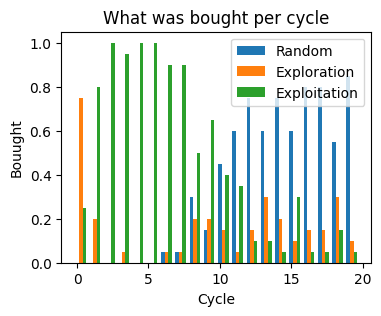

In [10]:
buy_matrix_mean = np.mean(buy_matrix, axis=0)
bought_random_mean = buy_matrix_mean[:, 0]
bought_diverse_mean = buy_matrix_mean[:, 1]
bought_uncertain_mean = buy_matrix_mean[:, 2]
labels = ['Random', 'Exploration', 'Exploitation']

plt.plot(bought_random_mean )
plt.plot(bought_diverse_mean )
plt.plot(bought_uncertain_mean )
plt.show()

bar_width = 0.25  # Width of the bars
x = np.arange(len(bought_random_mean)) # Position of bars on x-axis
fig, ax = plt.subplots()
for i, vals in enumerate([bought_random_mean, bought_diverse_mean, bought_uncertain_mean]):
    ax.bar(x + i * bar_width, vals, width=bar_width, label=labels[i])

#zoom_ax = fig.add_axes([0.25, 0.5, 0.25, 0.35])  # (x_position, y_position, width, height)

# Adding value labels on top of each bar
# Set the labels
ax.set_xlabel('Cycle')
ax.set_ylabel('Bouught')
ax.set_title('What was bought per cycle')
ax.legend()
plt.show()


In [11]:
seed = 1
runs = [run for run in runs_per_strat['perf_900']]
runs = filter(lambda x: x.data.params['random_seed'] == f'{seed}', runs)
run = list(runs)[0]
artifact_path = download_artifacts(run)

with open(artifact_path / f'artifacts_cycle20', "r") as f:
    data = json.load(f)


receiving incremental file list
./
artifacts_cycle00
artifacts_cycle01
artifacts_cycle02
artifacts_cycle03
artifacts_cycle04
artifacts_cycle05
artifacts_cycle06
artifacts_cycle07
artifacts_cycle08
artifacts_cycle09
artifacts_cycle10
artifacts_cycle11
artifacts_cycle12
artifacts_cycle13
artifacts_cycle14
artifacts_cycle15
artifacts_cycle16
artifacts_cycle17
artifacts_cycle18
artifacts_cycle19
artifacts_cycle20

sent 426 bytes  received 339,804 bytes  226,820.00 bytes/sec
total size is 10,879,825  speedup is 31.98


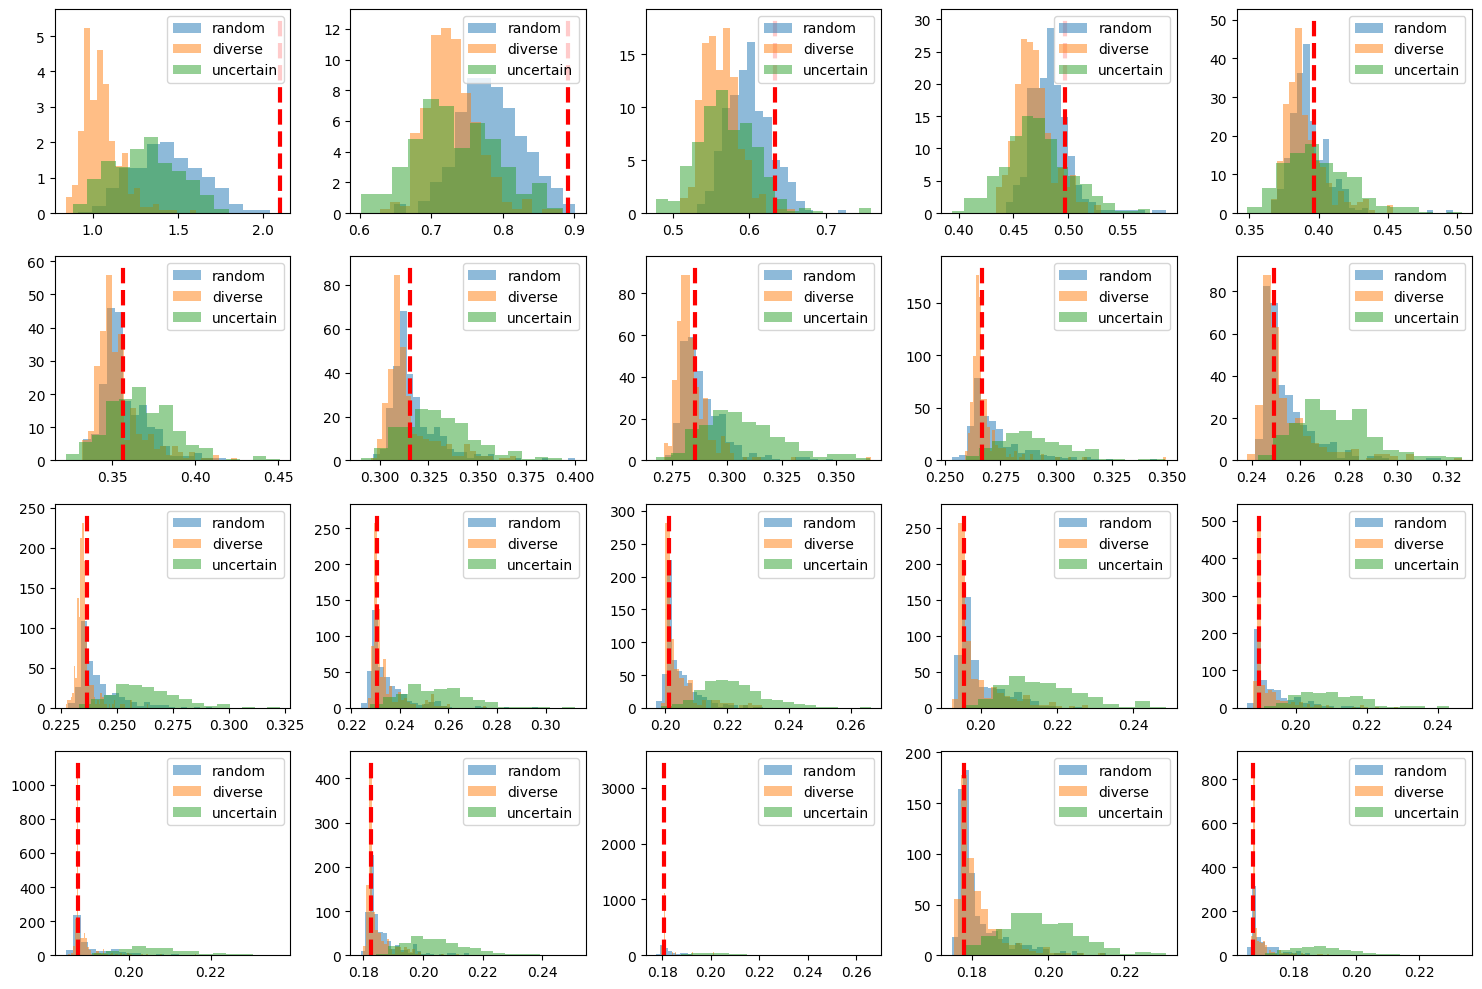

In [13]:
from copy import deepcopy
oracle_history = data['oracle_history']
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()
for i_cycle, d in enumerate(oracle_history):
    loss_batches = d['loss_batches']
    base_loss = d['base_loss']
    batches_counts = deepcopy(d['batches_counts'])

    # del batches_counts['random']
    # del batches_counts['diverse']
    # del batches_counts['uncertain']

    plt.sca(axes[i_cycle])
    losses_per_type = np.split(loss_batches, np.cumsum(list(batches_counts.values())[:-1]))
    for losses, type in zip(losses_per_type, batches_counts):
        plt.hist(losses, bins='auto', density=True, label=type, alpha=0.5)
    plt.vlines(base_loss, *plt.ylim(), colors='red', lw=3, ls='--')
    plt.legend()
plt.tight_layout()

In [3]:
from collections import defaultdict

exp_name = 'oracle_v4'
dataset = 'cifar10'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'

runs = []

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'random'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_)

for subset_size in [100, 500, 1000, 5000, 10000, None]:
    query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'perf_dal_oracle'", f"parameter.al.subset_size = '{subset_size}'"]
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    runs_ = [rename_parameter(run, 'al.strategy', run.data.params['al.subset_size']) for run in runs_]
    runs.extend(runs_)


# runs1 = filter_by_date(runs, 2024, 11, 29, 13, 10, fn=np.less)
# runs2 = filter_by_date(runs, 2024, 11, 29, 15, 50)
# runs = runs1 + runs2

print('Found {} experiments'.format(len(runs)))


runs_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

acc_curves_random = acc_curves_strategies['random']

for key in  acc_curves_strategies:
    print(f"{key:10}: {len(acc_curves_strategies[key]):3}")

# run = runs_per_strat['optimal'][0]
# params = run.data.params
# {key: val for key, val in params.items() if key.startswith('al')}

Found 140 experiments
random    :  20
100       :  20
500       :  20
1000      :  20
5000      :  20
10000     :  20
None      :  20


In [6]:
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)
axis_single = np.arange(acq_size, (acq_size*(num_acq+1))+1, 1)

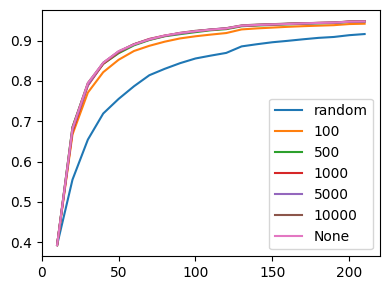

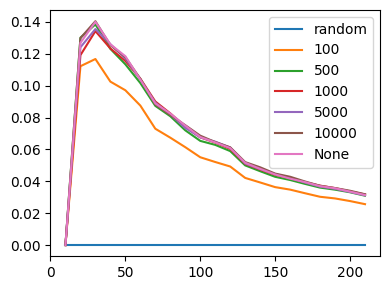

In [8]:
plt.figure(figsize=(4, 3))

for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), label=key)

plt.tight_layout()
plt.legend()

plt.figure(figsize=(4, 3))

acc_random = np.mean(acc_curves_random, axis=0)
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - acc_random , label=key)

plt.tight_layout()
plt.legend()

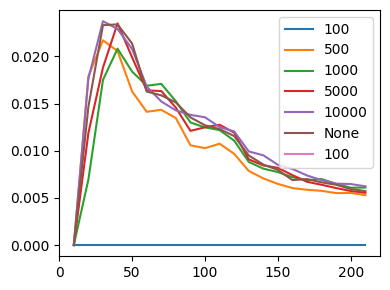

In [21]:
plt.figure(figsize=(4, 3))

base = np.mean(acc_curves_strategies['100'], axis=0)
for key in acc_curves_strategies:
    if key == 'random': continue
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - base, label=key)

plt.tight_layout()
plt.legend()

In [ ]:

base

[[0.38749998807907104,
  0.6837000250816345,
  0.7705000042915344,
  0.8266000151634216,
  0.8514000177383423,
  0.8705000281333923,
  0.8867999911308289,
  0.8992999792098999,
  0.9100000262260437,
  0.9153000116348267,
  0.9190000295639038,
  0.921999990940094,
  0.9269000291824341,
  0.9323999881744385,
  0.932699978351593,
  0.9351000189781189,
  0.9366000294685364,
  0.9390000104904175,
  0.939300000667572,
  0.9427000284194946,
  0.9416000247001648],
 [0.45260000228881836,
  0.7311999797821045,
  0.8027999997138977,
  0.8428000211715698,
  0.866599977016449,
  0.8798999786376953,
  0.8966000080108643,
  0.9079999923706055,
  0.9106000065803528,
  0.911899983882904,
  0.9156000018119812,
  0.9215999841690063,
  0.9280999898910522,
  0.9298999905586243,
  0.9332000017166138,
  0.9341999888420105,
  0.9355999827384949,
  0.9372000098228455,
  0.9383999705314636,
  0.9406999945640564,
  0.9415000081062317],
 [0.3483000099658966,
  0.7026000022888184,
  0.8001000285148621,
  0.8449000